# **Project Name**    - Vaccination Data Analysis and Visualization

##### **Project Type**    - EDA/Data Analysis
##### **Contribution**    - Individual
##### **Team Member 1 - Saloumi Mitre**
##### **Team Member 2 - N/A**
##### **Team Member 3 - N/A**
##### **Team Member 4 - N/A**

# **Project Summary -**

The Vaccination Data Analysis Project focuses on analyzing vaccination coverage and its relationship with disease incidence across different countries and years. The project uses multiple datasets containing information about vaccination coverage, disease incidence rates, reported cases, vaccine introduction, and vaccination schedules.

The project begins with data cleaning and preprocessing using Python to handle missing values, inconsistent data formats, duplicate records, and other data quality issues. Exploratory Data Analysis (EDA) is then performed to identify important patterns, trends, and relationships within the datasets. Vaccination coverage is analyzed using factors such as the number of doses administered and the target population.

The cleaned datasets are organized and stored in an SQL database, where appropriate relationships between different datasets are established. SQL queries are used to retrieve, filter, combine, and analyze the data efficiently. The project also examines the relationship between vaccination coverage and disease incidence to understand how changes in vaccination levels are associated with reported disease trends.

Finally, Power BI is used to create interactive dashboards and visualizations. These dashboards present important KPIs, country-wise vaccination coverage, disease trends, geographical comparisons, vaccination patterns, and relationships between vaccination coverage and disease incidence. The combination of Python, SQL, and Power BI provides an end-to-end approach for transforming raw vaccination data into meaningful insights.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**

**To analyze vaccination coverage and disease incidence across different countries and years by cleaning, integrating, and exploring vaccination-related datasets to identify important trends, patterns, and relationships that can support data-driven public health insights.**

#### **Define Your Business Objective?**

To identify vaccination coverage patterns, compare vaccination levels across countries and years, analyze their relationship with disease incidence, and present actionable insights through data analysis and interactive visualizations.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





## 1. Setup and Input Data

In [1]:
import sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

BASE = Path.cwd()
DB_PATH = BASE / "vaccination.db"
CHART_DIR = BASE / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)

RAW_FILES = {
    "coverage": BASE / "coverage_data.csv",
    "incidence": BASE / "incidence_rate.csv",
    "cases": BASE / "reported_cases.csv",
    "intro": BASE / "vaccine_introduction.csv",
    "schedule": BASE / "vaccine_schedule_data.csv",
}

missing_files = [p.name for p in RAW_FILES.values() if not p.exists()]
assert not missing_files, (
    "Required CSV files not found in the notebook folder: "
    + ", ".join(missing_files)
)

print("Project folder:", BASE)
print("All required input CSV files found.")


Project folder: C:\Users\Saloumi\Vaccination Project (Labmentix)
All required input CSV files found.


## 2. Helper Functions for Data Cleaning

In [2]:
VALID_YEAR_RANGE = (1990, 2025)

def snake(col: str) -> str:
    return col.strip().lower().replace(" ", "_").replace("-", "_").replace("__", "_")

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [snake(c) for c in df.columns]
    return df

def clean_year(df: pd.DataFrame, col="year") -> pd.DataFrame:
    df = df.copy()
    df[col] = pd.to_numeric(df[col], errors="coerce")
    before = len(df)
    df = df[df[col].between(*VALID_YEAR_RANGE)].copy()
    df[col] = df[col].astype(int)
    dropped = before - len(df)
    if dropped:
        print(f"    dropped {dropped:,} rows with invalid/out-of-range year")
    return df

def report(name, before, after):
    print(f"  {name}: {before:,} -> {after:,} rows after cleaning")

def savefig(name):
    path = CHART_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=130, bbox_inches="tight")
    print(f"  saved: {path.name}")
    plt.show()


## 3. Clean Table 1 — Coverage Data

In [3]:
print("Cleaning coverage_data.csv ...")
df = pd.read_csv(RAW_FILES["coverage"])
before = len(df)
df = standardize_columns(df)
df = df.drop_duplicates()
df = clean_year(df)

df["coverage"] = pd.to_numeric(df["coverage"], errors="coerce")
df["coverage"] = df["coverage"].clip(lower=0, upper=100)

df["coverage"] = df.groupby(
    ["antigen", "coverage_category"]
)["coverage"].transform(lambda s: s.fillna(s.median()))
df["coverage"] = df["coverage"].fillna(df["coverage"].median())

df["target_number"] = pd.to_numeric(df["target_number"], errors="coerce")
df["doses"] = pd.to_numeric(df["doses"], errors="coerce")

can_backfill = (
    df["target_number"].isna()
    & df["doses"].notna()
    & (df["coverage"] > 0)
)
df.loc[can_backfill, "target_number"] = (
    df.loc[can_backfill, "doses"] /
    (df.loc[can_backfill, "coverage"] / 100)
).round()

df = df.dropna(subset=["target_number", "doses"]).copy()
df["target_number"] = df["target_number"].astype(int)
df["doses"] = df["doses"].astype(int)

df["coverage_category"] = df["coverage_category"].astype(str).str.strip().str.upper()
df["code"] = df["code"].astype(str).str.strip().str.upper()
df["name"] = df["name"].astype(str).str.strip()

report("coverage_data", before, len(df))
coverage_clean = df.copy()
coverage_clean.head()


Cleaning coverage_data.csv ...
  coverage_data: 5,090 -> 5,040 rows after cleaning


,group,code,name,year,antigen,antigen_description,coverage_category,coverage_category_description,target_number,doses,coverage
0,COUNTRIES,IND,India,2010,BCG,Bacille Calmette-Guerin (Tuberculosis),ADMIN,Administrative coverage (doses given / target ...,2279774,1942316,85.2
1,COUNTRIES,IND,India,2010,BCG,Bacille Calmette-Guerin (Tuberculosis),OFFICIAL,Official country-reported coverage estimate,1174831,907345,77.2
2,COUNTRIES,IND,India,2010,BCG,Bacille Calmette-Guerin (Tuberculosis),WUENIC,WHO/UNICEF Estimates of National Immunization ...,4298541,3554279,82.7
3,COUNTRIES,IND,India,2010,DTP1,Diphtheria/Tetanus/Pertussis - 1st dose,ADMIN,Administrative coverage (doses given / target ...,4146774,3395216,81.9
4,COUNTRIES,IND,India,2010,DTP1,Diphtheria/Tetanus/Pertussis - 1st dose,OFFICIAL,Official country-reported coverage estimate,3517588,3177103,90.3


## 4. Clean Table 2 — Incidence Rate

In [4]:
print("Cleaning incidence_rate.csv ...")
df = pd.read_csv(RAW_FILES["incidence"])
before = len(df)
df = standardize_columns(df)
df = df.drop_duplicates()
df = clean_year(df)

df["incidence_rate"] = pd.to_numeric(df["incidence_rate"], errors="coerce")
df["incidence_rate"] = df["incidence_rate"].clip(lower=0)

df["incidence_rate"] = df.groupby(
    ["disease", "denominator"]
)["incidence_rate"].transform(lambda s: s.fillna(s.median()))
df = df.dropna(subset=["incidence_rate"]).copy()

df["denominator"] = df["denominator"].astype(str).str.strip().str.lower()
df["code"] = df["code"].astype(str).str.strip().str.upper()
df["disease"] = df["disease"].astype(str).str.strip().str.upper()

report("incidence_rate", before, len(df))
incidence_clean = df.copy()
incidence_clean.head()


Cleaning incidence_rate.csv ...
  incidence_rate: 1,260 -> 1,260 rows after cleaning


,group,code,name,year,disease,disease_description,denominator,incidence_rate
0,COUNTRIES,IND,India,2010,MEASLES,Measles,"per 1,000,000 population",9.70
1,COUNTRIES,IND,India,2010,POLIO,Poliomyelitis,"per 1,000,000 population",12.92
2,COUNTRIES,IND,India,2010,PERTUSSIS,Pertussis (Whooping cough),"per 1,000 live births",21.03
3,COUNTRIES,IND,India,2010,DIPHTHERIA,Diphtheria,"per 100,000 population",4.62
4,COUNTRIES,IND,India,2010,TB,Tuberculosis,"per 1,000 live births",2.98


## 5. Clean Table 3 — Reported Cases

In [5]:
print("Cleaning reported_cases.csv ...")
df = pd.read_csv(RAW_FILES["cases"])
before = len(df)
df = standardize_columns(df)
df = df.drop_duplicates()
df = clean_year(df)

df["cases"] = pd.to_numeric(df["cases"], errors="coerce")
df["cases"] = df["cases"].clip(lower=0)
df["cases"] = df["cases"].fillna(0).astype(int)

df["code"] = df["code"].astype(str).str.strip().str.upper()
df["disease"] = df["disease"].astype(str).str.strip().str.upper()

report("reported_cases", before, len(df))
cases_clean = df.copy()
cases_clean.head()


Cleaning reported_cases.csv ...
  reported_cases: 1,260 -> 1,260 rows after cleaning


,group,code,name,year,disease,disease_description,cases
0,COUNTRIES,IND,India,2010,MEASLES,Measles,204
1,COUNTRIES,IND,India,2010,POLIO,Poliomyelitis,603
2,COUNTRIES,IND,India,2010,PERTUSSIS,Pertussis (Whooping cough),166
3,COUNTRIES,IND,India,2010,DIPHTHERIA,Diphtheria,52
4,COUNTRIES,IND,India,2010,TB,Tuberculosis,127


## 6. Clean Table 4 — Vaccine Introduction

In [6]:
print("Cleaning vaccine_introduction.csv ...")
df = pd.read_csv(RAW_FILES["intro"])
before = len(df)
df = standardize_columns(df)
df = df.drop_duplicates()
df = clean_year(df)

df["intro"] = df["intro"].astype(str).str.strip().str.lower().map({
    "yes": True, "y": True, "1": True, "true": True,
    "no": False, "n": False, "0": False, "false": False,
})

df = df.dropna(subset=["intro"]).copy()
df["intro"] = df["intro"].astype(bool)
df["iso_3_code"] = df["iso_3_code"].astype(str).str.strip().str.upper()
df["who_region"] = df["who_region"].astype(str).str.strip().str.upper()

report("vaccine_introduction", before, len(df))
intro_clean = df.copy()
intro_clean.head()


Cleaning vaccine_introduction.csv ...
  vaccine_introduction: 1,680 -> 1,680 rows after cleaning


,iso_3_code,country_name,who_region,year,description,intro
0,IND,India,SEARO,2010,Bacille Calmette-Guerin (Tuberculosis),True
1,IND,India,SEARO,2011,Bacille Calmette-Guerin (Tuberculosis),True
2,IND,India,SEARO,2012,Bacille Calmette-Guerin (Tuberculosis),True
3,IND,India,SEARO,2013,Bacille Calmette-Guerin (Tuberculosis),True
4,IND,India,SEARO,2014,Bacille Calmette-Guerin (Tuberculosis),True


## 7. Clean Table 5 — Vaccine Schedule Data

In [7]:
print("Cleaning vaccine_schedule_data.csv ...")
df = pd.read_csv(RAW_FILES["schedule"])
before = len(df)
df = standardize_columns(df)
df = df.drop_duplicates()
df = clean_year(df)

df["schedule_rounds"] = pd.to_numeric(
    df["schedule_rounds"], errors="coerce"
).fillna(1).astype(int)

df["iso_3_code"] = df["iso_3_code"].astype(str).str.strip().str.upper()
df["who_region"] = df["who_region"].astype(str).str.strip().str.upper()
df["source_comment"] = df["source_comment"].fillna("").astype(str).str.strip()
df["age_administered"] = df["age_administered"].fillna("N/A")

report("vaccine_schedule_data", before, len(df))
schedule_clean = df.copy()
schedule_clean.head()


Cleaning vaccine_schedule_data.csv ...
  vaccine_schedule_data: 935 -> 935 rows after cleaning


,iso_3_code,country_name,who_region,year,vaccine_code,vaccine_description,schedule_rounds,target_pop,target_pop_description,geoarea,age_administered,source_comment
0,IND,India,SEARO,2018,BCG,Bacille Calmette-Guerin (Tuberculosis),1,ELDERLY,Adults 65+,NATIONAL,N/A,Reported via national immunization program
1,IND,India,SEARO,2018,BCG,Bacille Calmette-Guerin (Tuberculosis),2,INFANT,Infants under 1 year,NATIONAL,16 months,Reported via national immunization program
2,IND,India,SEARO,2018,DTP1,Diphtheria/Tetanus/Pertussis - 1st dose,1,CHILD,Children 1-5 years,NATIONAL,0 months,
3,IND,India,SEARO,2018,DTP1,Diphtheria/Tetanus/Pertussis - 1st dose,2,ELDERLY,Adults 65+,NATIONAL,N/A,
4,IND,India,SEARO,2018,DTP3,Diphtheria/Tetanus/Pertussis - 3rd dose,1,CHILD,Children 1-5 years,NATIONAL,13 months,Reported via national immunization program


## 8. Cleaning Summary

In [8]:
clean_tables = {
    "coverage_data": coverage_clean,
    "incidence_rate": incidence_clean,
    "reported_cases": cases_clean,
    "vaccine_introduction": intro_clean,
    "vaccine_schedule_data": schedule_clean,
}

print("All 5 tables cleaned successfully.\n")
for name, table in clean_tables.items():
    print(f"{name:25s} {table.shape[0]:>8,} rows x {table.shape[1]:>3} columns")


All 5 tables cleaned successfully.

coverage_data                5,040 rows x  11 columns
incidence_rate               1,260 rows x   8 columns
reported_cases               1,260 rows x   7 columns
vaccine_introduction         1,680 rows x   6 columns
vaccine_schedule_data          935 rows x  12 columns


## 9. Create SQLite Database

In [9]:
if DB_PATH.exists():
    DB_PATH.unlink()
    print("Removed existing database to rebuild from scratch.")

conn = sqlite3.connect(DB_PATH)
cur = conn.cursor()

schema_sql = '''
PRAGMA foreign_keys = ON;

CREATE TABLE dim_country (
    country_code TEXT PRIMARY KEY,
    country_name TEXT NOT NULL,
    who_region TEXT
);

CREATE TABLE dim_disease (
    disease_code TEXT PRIMARY KEY,
    disease_description TEXT
);

CREATE TABLE dim_vaccine (
    vaccine_code TEXT PRIMARY KEY,
    vaccine_description TEXT
);

CREATE TABLE fact_coverage (
    coverage_id INTEGER PRIMARY KEY AUTOINCREMENT,
    country_code TEXT NOT NULL,
    year INTEGER NOT NULL,
    vaccine_code TEXT NOT NULL,
    coverage_category TEXT NOT NULL,
    coverage_category_desc TEXT,
    target_number INTEGER,
    doses INTEGER,
    coverage_pct REAL CHECK (coverage_pct BETWEEN 0 AND 100),
    FOREIGN KEY (country_code) REFERENCES dim_country(country_code),
    FOREIGN KEY (vaccine_code) REFERENCES dim_vaccine(vaccine_code)
);

CREATE TABLE fact_incidence (
    incidence_id INTEGER PRIMARY KEY AUTOINCREMENT,
    country_code TEXT NOT NULL,
    year INTEGER NOT NULL,
    disease_code TEXT NOT NULL,
    denominator TEXT,
    incidence_rate REAL CHECK (incidence_rate >= 0),
    FOREIGN KEY (country_code) REFERENCES dim_country(country_code),
    FOREIGN KEY (disease_code) REFERENCES dim_disease(disease_code)
);

CREATE TABLE fact_reported_cases (
    case_id INTEGER PRIMARY KEY AUTOINCREMENT,
    country_code TEXT NOT NULL,
    year INTEGER NOT NULL,
    disease_code TEXT NOT NULL,
    cases INTEGER CHECK (cases >= 0),
    FOREIGN KEY (country_code) REFERENCES dim_country(country_code),
    FOREIGN KEY (disease_code) REFERENCES dim_disease(disease_code)
);

CREATE TABLE fact_vaccine_introduction (
    intro_id INTEGER PRIMARY KEY AUTOINCREMENT,
    country_code TEXT NOT NULL,
    who_region TEXT,
    year INTEGER NOT NULL,
    vaccine_description TEXT,
    introduced INTEGER CHECK (introduced IN (0, 1)),
    FOREIGN KEY (country_code) REFERENCES dim_country(country_code)
);

CREATE TABLE fact_vaccine_schedule (
    schedule_id INTEGER PRIMARY KEY AUTOINCREMENT,
    country_code TEXT NOT NULL,
    who_region TEXT,
    year INTEGER NOT NULL,
    vaccine_code TEXT,
    schedule_rounds INTEGER,
    target_pop TEXT,
    target_pop_description TEXT,
    geoarea TEXT,
    age_administered TEXT,
    source_comment TEXT,
    FOREIGN KEY (country_code) REFERENCES dim_country(country_code),
    FOREIGN KEY (vaccine_code) REFERENCES dim_vaccine(vaccine_code)
);

CREATE INDEX idx_coverage_country_year
    ON fact_coverage(country_code, year);

CREATE INDEX idx_coverage_vaccine
    ON fact_coverage(vaccine_code);

CREATE INDEX idx_incidence_country_year
    ON fact_incidence(country_code, year);

CREATE INDEX idx_incidence_disease
    ON fact_incidence(disease_code);

CREATE INDEX idx_cases_country_year
    ON fact_reported_cases(country_code, year);

CREATE INDEX idx_cases_disease
    ON fact_reported_cases(disease_code);

CREATE INDEX idx_intro_country_year
    ON fact_vaccine_introduction(country_code, year);

CREATE INDEX idx_schedule_country_year
    ON fact_vaccine_schedule(country_code, year);
'''

cur.executescript(schema_sql)
conn.commit()

print("SQLite schema created:", DB_PATH.name)

Removed existing database to rebuild from scratch.
SQLite schema created: vaccination.db


## 10. Load Cleaned Data into SQLite

In [10]:
# ============================================================
# Load Dimensions and Fact Tables into SQLite
# ============================================================

coverage = coverage_clean.copy()
incidence = incidence_clean.copy()
cases = cases_clean.copy()
intro = intro_clean.copy()
schedule = schedule_clean.copy()


# ============================================================
# DIMENSION TABLE: COUNTRY
# ============================================================

dim_country = pd.concat([
    coverage[["code", "name"]].rename(
        columns={
            "code": "country_code",
            "name": "country_name"
        }
    ),
    incidence[["code", "name"]].rename(
        columns={
            "code": "country_code",
            "name": "country_name"
        }
    ),
    cases[["code", "name"]].rename(
        columns={
            "code": "country_code",
            "name": "country_name"
        }
    ),
]).drop_duplicates(subset="country_code")


who_region_lookup = pd.concat([
    intro[["iso_3_code", "who_region"]].rename(
        columns={"iso_3_code": "country_code"}
    ),
    schedule[["iso_3_code", "who_region"]].rename(
        columns={"iso_3_code": "country_code"}
    ),
]).drop_duplicates(subset="country_code")


dim_country = dim_country.merge(
    who_region_lookup,
    on="country_code",
    how="left"
)

dim_country.to_sql(
    "dim_country",
    conn,
    if_exists="append",
    index=False
)


# ============================================================
# DIMENSION TABLE: DISEASE
# ============================================================

dim_disease = pd.concat([
    incidence[["disease", "disease_description"]],
    cases[["disease", "disease_description"]]
]).drop_duplicates(
    subset="disease"
).rename(
    columns={
        "disease": "disease_code"
    }
)

dim_disease.to_sql(
    "dim_disease",
    conn,
    if_exists="append",
    index=False
)


# ============================================================
# DIMENSION TABLE: VACCINE
# ============================================================

dim_vaccine = coverage[
    ["antigen", "antigen_description"]
].drop_duplicates(
    subset="antigen"
).rename(
    columns={
        "antigen": "vaccine_code",
        "antigen_description": "vaccine_description"
    }
)

dim_vaccine.to_sql(
    "dim_vaccine",
    conn,
    if_exists="append",
    index=False
)


# ============================================================
# FACT TABLE: COVERAGE
# ============================================================

fact_coverage = coverage.rename(columns={
    "code": "country_code",
    "antigen": "vaccine_code",
    "coverage_category_description": "coverage_category_desc",
    "coverage": "coverage_pct"
})[
    [
        "country_code",
        "year",
        "vaccine_code",
        "coverage_category",
        "coverage_category_desc",
        "target_number",
        "doses",
        "coverage_pct"
    ]
]

fact_coverage.to_sql(
    "fact_coverage",
    conn,
    if_exists="append",
    index=False
)


# ============================================================
# FACT TABLE: INCIDENCE
# ============================================================

fact_incidence = incidence.rename(columns={
    "code": "country_code",
    "disease": "disease_code"
})[
    [
        "country_code",
        "year",
        "disease_code",
        "denominator",
        "incidence_rate"
    ]
]

fact_incidence.to_sql(
    "fact_incidence",
    conn,
    if_exists="append",
    index=False
)


# ============================================================
# FACT TABLE: REPORTED CASES
# ============================================================

fact_cases = cases.rename(columns={
    "code": "country_code",
    "disease": "disease_code"
})[
    [
        "country_code",
        "year",
        "disease_code",
        "cases"
    ]
]

fact_cases.to_sql(
    "fact_reported_cases",
    conn,
    if_exists="append",
    index=False
)


# ============================================================
# FACT TABLE: VACCINE INTRODUCTION
# ============================================================

fact_intro = intro.rename(columns={
    "iso_3_code": "country_code",
    "description": "vaccine_description",
    "intro": "introduced"
})

fact_intro["introduced"] = fact_intro["introduced"].astype(int)

fact_intro = fact_intro[
    [
        "country_code",
        "who_region",
        "year",
        "vaccine_description",
        "introduced"
    ]
]

fact_intro.to_sql(
    "fact_vaccine_introduction",
    conn,
    if_exists="append",
    index=False
)


# ============================================================
# FACT TABLE: VACCINE SCHEDULE
# ============================================================

fact_schedule = schedule.rename(columns={
    "iso_3_code": "country_code"
})[
    [
        "country_code",
        "who_region",
        "year",
        "vaccine_code",
        "schedule_rounds",
        "target_pop",
        "target_pop_description",
        "geoarea",
        "age_administered",
        "source_comment"
    ]
]

fact_schedule.to_sql(
    "fact_vaccine_schedule",
    conn,
    if_exists="append",
    index=False
)


# ============================================================
# COMMIT DATA
# ============================================================

conn.commit()

print("✅ All 5 fact tables loaded successfully.")

# Display database tables for verification
print("\nDatabase tables:")

print(pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name
    """,
    conn
))

✅ All 5 fact tables loaded successfully.

Database tables:
                        name
0                dim_country
1                dim_disease
2                dim_vaccine
3              fact_coverage
4             fact_incidence
5        fact_reported_cases
6  fact_vaccine_introduction
7      fact_vaccine_schedule
8            sqlite_sequence


## 11. Database Sanity Check

In [11]:
tables = [
    "dim_country",
    "dim_disease",
    "dim_vaccine",
    "fact_coverage",
    "fact_incidence",
    "fact_reported_cases",
    "fact_vaccine_introduction",
    "fact_vaccine_schedule",
]

print("Row counts loaded:")
for tbl in tables:
    n = cur.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()[0]
    print(f"  {tbl:30s} {n:>10,} rows")


Row counts loaded:
  dim_country                            15 rows
  dim_disease                             6 rows
  dim_vaccine                             8 rows
  fact_coverage                       5,040 rows
  fact_incidence                      1,260 rows
  fact_reported_cases                 1,260 rows
  fact_vaccine_introduction           1,680 rows
  fact_vaccine_schedule                 935 rows


## 12. Exploratory Data Analysis (EDA)

### 12.1 Coverage vs. Incidence Trend

  saved: 01_coverage_vs_incidence_trend.png


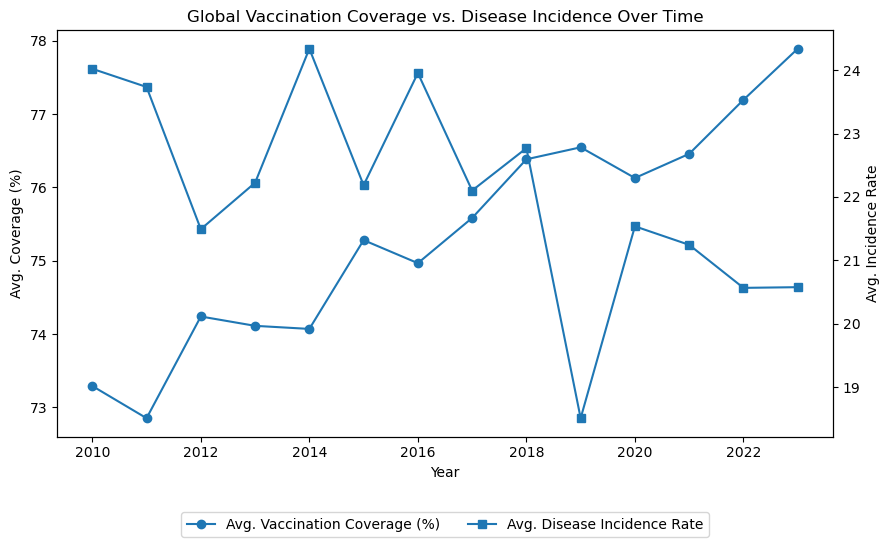

Correlation (coverage vs incidence): -0.72


In [12]:
q = '''
SELECT c.year,
       AVG(c.coverage_pct) AS avg_coverage,
       AVG(i.incidence_rate) AS avg_incidence
FROM fact_coverage c
JOIN fact_incidence i
  ON c.country_code = i.country_code AND c.year = i.year
GROUP BY c.year
ORDER BY c.year
'''
df = pd.read_sql(q, conn)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.plot(df.year, df.avg_coverage, marker="o",
         label="Avg. Vaccination Coverage (%)")
ax2.plot(df.year, df.avg_incidence, marker="s",
         label="Avg. Disease Incidence Rate")

ax1.set_xlabel("Year")
ax1.set_ylabel("Avg. Coverage (%)")
ax2.set_ylabel("Avg. Incidence Rate")
ax1.set_title("Global Vaccination Coverage vs. Disease Incidence Over Time")

fig.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2)
savefig("01_coverage_vs_incidence_trend.png")

corr = df["avg_coverage"].corr(df["avg_incidence"])
print(f"Correlation (coverage vs incidence): {corr:.2f}")


### 12.2 DTP1 → DTP3 Drop-off by Country

  saved: 02_dtp1_dtp3_dropoff.png


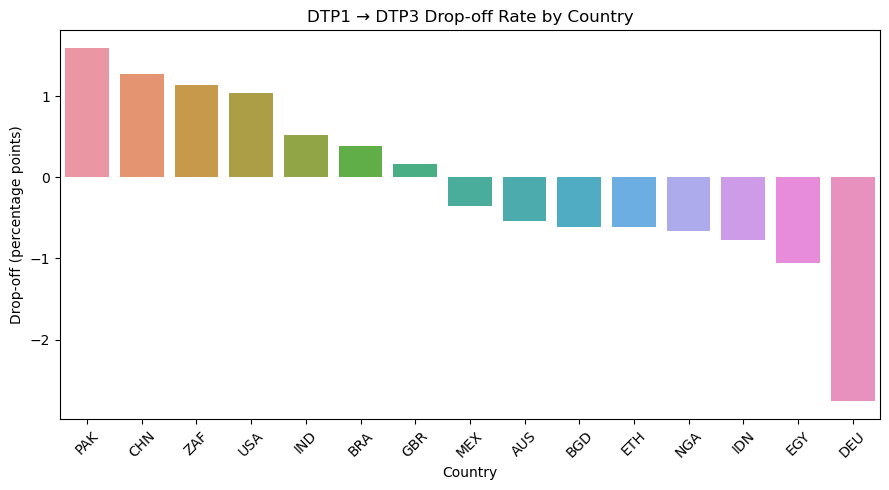

In [13]:
q = '''
SELECT country_code,
       AVG(CASE WHEN vaccine_code='DTP1' THEN coverage_pct END) AS dtp1,
       AVG(CASE WHEN vaccine_code='DTP3' THEN coverage_pct END) AS dtp3
FROM fact_coverage
WHERE vaccine_code IN ('DTP1','DTP3')
GROUP BY country_code
'''

df = pd.read_sql(q, conn)

df["dropoff"] = df["dtp1"] - df["dtp3"]
df = df.dropna(subset=["dropoff"])
df = df.sort_values("dropoff", ascending=False)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="country_code",
    y="dropoff"
)

plt.title("DTP1 → DTP3 Drop-off Rate by Country")
plt.ylabel("Drop-off (percentage points)")
plt.xlabel("Country")
plt.xticks(rotation=45)

savefig("02_dtp1_dtp3_dropoff.png")

### 12.3 Booster (MCV2) Uptake Trend

  saved: 03_mcv2_booster_trend.png


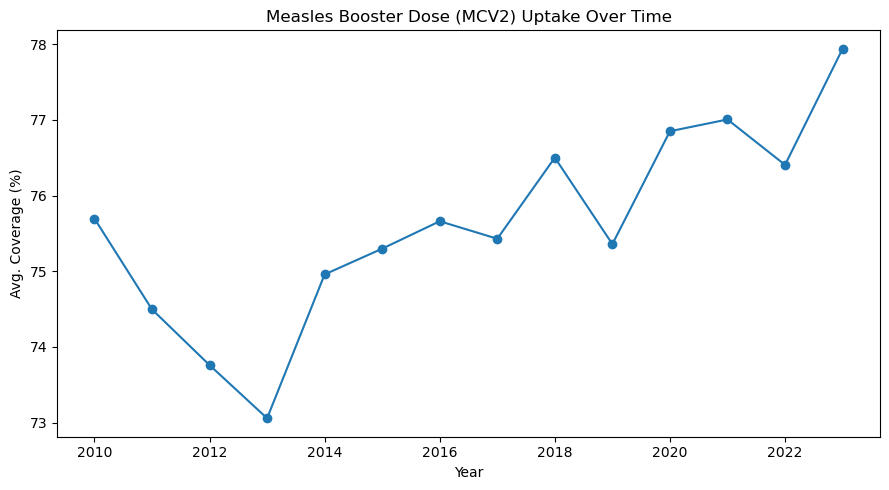

In [14]:
q = '''
SELECT year, AVG(coverage_pct) AS avg_mcv2
FROM fact_coverage
WHERE vaccine_code='MCV2'
GROUP BY year
ORDER BY year
'''
df = pd.read_sql(q, conn)

plt.figure(figsize=(9, 5))
plt.plot(df.year, df.avg_mcv2, marker="o")
plt.title("Measles Booster Dose (MCV2) Uptake Over Time")
plt.xlabel("Year")
plt.ylabel("Avg. Coverage (%)")
savefig("03_mcv2_booster_trend.png")


### 12.4 DTP3 Coverage Heatmap

  saved: 04_dtp3_coverage_heatmap.png


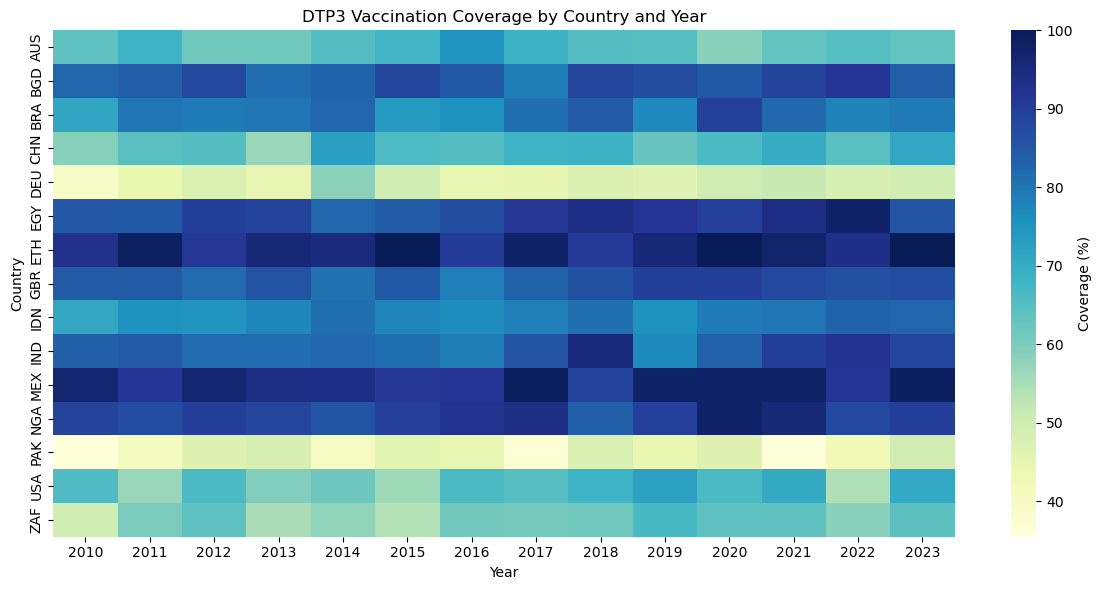

In [15]:
q = '''
SELECT country_code, year, coverage_pct
FROM fact_coverage
WHERE vaccine_code='DTP3'
'''
df = pd.read_sql(q, conn)

pivot = df.pivot_table(
    index="country_code",
    columns="year",
    values="coverage_pct",
    aggfunc="mean"
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot, cmap="YlGnBu", annot=False,
    cbar_kws={"label": "Coverage (%)"}
)
plt.title("DTP3 Vaccination Coverage by Country and Year")
plt.xlabel("Year")
plt.ylabel("Country")
savefig("04_dtp3_coverage_heatmap.png")


### 12.5 Coverage vs. Incidence Scatter

  saved: 05_coverage_incidence_scatter.png


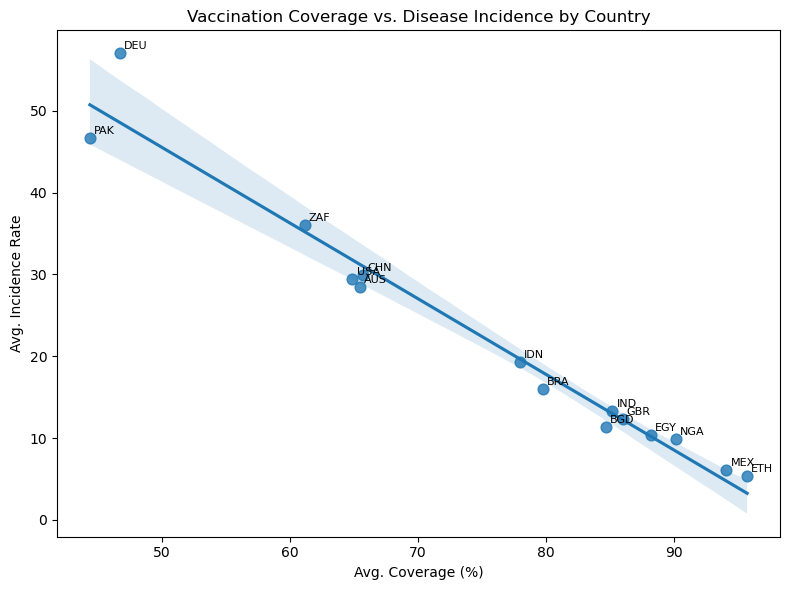

In [16]:
q = '''
SELECT c.country_code,
       AVG(c.coverage_pct) AS avg_coverage,
       AVG(i.incidence_rate) AS avg_incidence
FROM fact_coverage c
JOIN fact_incidence i
  ON c.country_code = i.country_code AND c.year = i.year
GROUP BY c.country_code
'''
df = pd.read_sql(q, conn)

plt.figure(figsize=(8, 6))
sns.regplot(
    data=df, x="avg_coverage", y="avg_incidence",
    scatter_kws={"s": 60}
)

for _, r in df.iterrows():
    plt.annotate(
        r.country_code,
        (r.avg_coverage, r.avg_incidence),
        fontsize=8, xytext=(3, 3), textcoords="offset points"
    )

plt.title("Vaccination Coverage vs. Disease Incidence by Country")
plt.xlabel("Avg. Coverage (%)")
plt.ylabel("Avg. Incidence Rate")
savefig("05_coverage_incidence_scatter.png")


### 12.6 Lowest-Coverage Countries

  saved: 06_lowest_coverage_countries.png


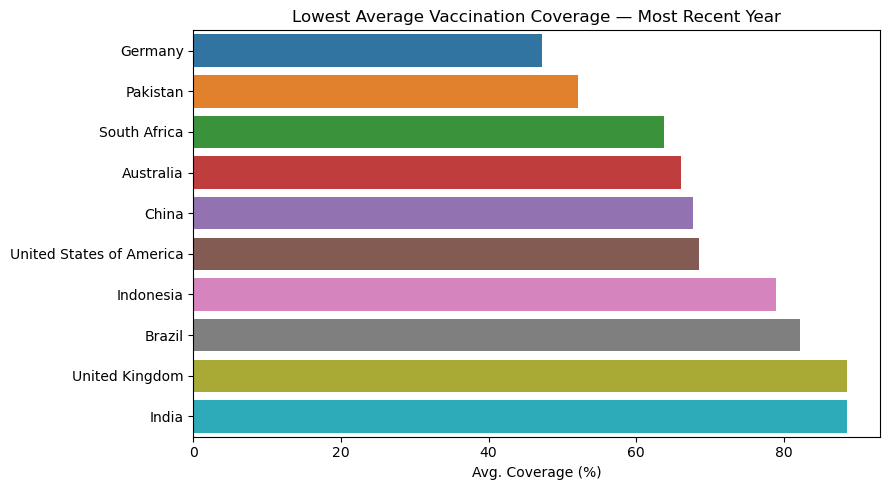

In [17]:
q = '''
SELECT dc.country_name,
       AVG(fc.coverage_pct) AS avg_coverage
FROM fact_coverage fc
JOIN dim_country dc
  ON dc.country_code = fc.country_code
WHERE fc.year = (SELECT MAX(year) FROM fact_coverage)
GROUP BY dc.country_name
ORDER BY avg_coverage ASC
LIMIT 10
'''

df = pd.read_sql(q, conn)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    y="country_name",
    x="avg_coverage"
)

plt.title("Lowest Average Vaccination Coverage — Most Recent Year")
plt.xlabel("Avg. Coverage (%)")
plt.ylabel("")

savefig("06_lowest_coverage_countries.png")

### 12.7 Progress Toward 95% MCV1 Target

  saved: 07_mcv1_target_progress.png


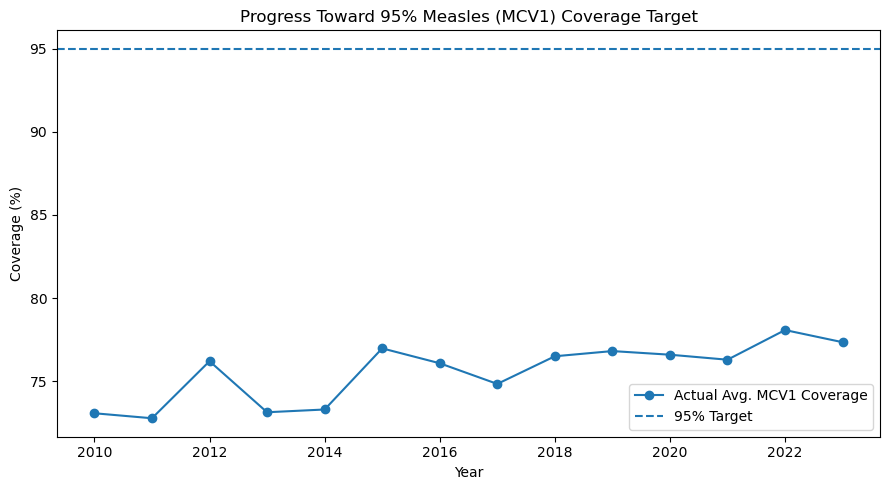

In [18]:
q = '''
SELECT year, AVG(coverage_pct) AS avg_mcv1
FROM fact_coverage
WHERE vaccine_code='MCV1'
GROUP BY year
ORDER BY year
'''
df = pd.read_sql(q, conn)

plt.figure(figsize=(9, 5))
plt.plot(df.year, df.avg_mcv1, marker="o",
         label="Actual Avg. MCV1 Coverage")
plt.axhline(95, linestyle="--", label="95% Target")
plt.title("Progress Toward 95% Measles (MCV1) Coverage Target")
plt.xlabel("Year")
plt.ylabel("Coverage (%)")
plt.legend()
savefig("07_mcv1_target_progress.png")


## 13. EDA Summary

In [19]:
print("EDA complete.")
print("Charts saved in:", CHART_DIR)
print("SQLite database:", DB_PATH)

conn.close()
print("Database connection closed.")


EDA complete.
Charts saved in: C:\Users\Saloumi\Vaccination Project (Labmentix)\charts
SQLite database: C:\Users\Saloumi\Vaccination Project (Labmentix)\vaccination.db
Database connection closed.


In [21]:
from pathlib import Path

print(Path.cwd())
print(DB_PATH.resolve())

C:\Users\Saloumi\Vaccination Project (Labmentix)
C:\Users\Saloumi\Vaccination Project (Labmentix)\vaccination.db
